# INF6422E – Advanced Concepts in Computer Security  
## Final project – Winter 2026  

### Comparing supervised vs unsupervised models for detecting known and zero-day attacks


--- 
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

---

## Objective

**Objective 1**

To evaluate the performance of a supervised and an unsupervised model in detecting known cyber attacks using labeled network traffic data.

**Objective 2**

To evaluate how both supervised and unsupervised models perform in detecting zero-day attacks using previously unseen network traffic.

**Objective 3**

To compare the trade-offs between supervised and unsupervised models in terms of detection accuracy, false positives, and overall reliability in cybersecurity applications.

---

## Dataset

This study uses the **CICIDS2017** dataset, combining:
- **Monday traffic** (Benign baseline used to learn normal network behavior)
- **Tuesday traffic** (Benign + Brute Force attacks used as known attack data for supervised training)
- **Thursday traffic** (Benign + Web Attacks used as a **zero-day dataset**, not seen during training)

---

## Notebook Structure

1. **Data Loading**
   - Load Monday, Tuesday, and Thursday datasets
   - Combine Monday and Tuesday as training data
   - Use Thursday as zero-day testing data

2. **Data Cleaning and Preparation**
   - Remove missing and infinite values
   - Create binary labels (Benign vs Attack)
   - Separate features and labels
   - Standardize features and encode labels

3. **Supervised Learning (Random Forest)**
   - Split known data into training and test sets
   - Train Random Forest classifier
   - Evaluate performance on known attacks
   - Test model on zero-day attacks
   - Generate confusion matrices, ROC curve, and feature importance

4. **Unsupervised Learning (Isolation Forest)**
   - Train model using only benign traffic
   - Test multiple contamination values
   - Detect anomalies in zero-day dataset
   - Analyze anomaly score distributions
   - Generate confusion matrix and ROC-AUC score

5. **Results and Analysis**
   - Compare supervised and unsupervised performance
   - Analyze detection capability and trade-offs between models


# 1. Data Loading

### Dataset Construction (Monday + Tuesday + Thursday – Zero-Day Setup)

- **Monday-WorkingHours.pcap_ISCX**: contains only benign (normal) traffic and is used to train the models on normal network behavior.

-  **Tuesday-WorkingHours.pcap_ISCX**: contains benign traffic mixed with brute-force attacks and is used to train the supervised model on known attack types.

-  **Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX**: contains web-based attacks and is used exclusively as a zero-day dataset. These attacks are not included during training, allowing evaluation of the models’ ability to detect previously unseen threats.

The following steps load the selected CSV files and construct separate datasets for training and zero-day testing.


In [18]:
import pandas as pd
import numpy as np

# File paths
monday_path = "Monday-WorkingHours.pcap_ISCX.csv"
tuesday_path = "Tuesday-WorkingHours.pcap_ISCX.csv"
thursday_path = "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"

# Load datasets
df_monday = pd.read_csv(monday_path)
df_tuesday = pd.read_csv(tuesday_path)
df_thursday = pd.read_csv(thursday_path)

print("Monday:", df_monday.shape)
print("Tuesday:", df_tuesday.shape)
print("Thursday:", df_thursday.shape)

# Training dataset (Known behavior)
df_train = pd.concat(
    [df_monday, df_tuesday],
    axis=0,
    ignore_index=True
)

# Zero-day dataset
df_zero_day = df_thursday.copy()

print("Training dataset:", df_train.shape)
print("Zero-day dataset:", df_zero_day.shape)



Monday: (529918, 79)
Tuesday: (445909, 79)
Thursday: (170366, 79)
Training dataset: (975827, 79)
Zero-day dataset: (170366, 79)


## 2. Data Cleaning and Preparation

### Removing missing and infinite values
### Creating binary labels (Benign vs Attack)

In [19]:
for df in [df_train, df_zero_day]:

    # Clean column names
    df.columns = df.columns.str.strip()

    # Replace infinite values
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Drop missing values
    df.dropna(inplace=True)

    # Create Binary Label
    df["BinaryLabel"] = df["Label"].apply(
        lambda x: "Benign" if x == "BENIGN" else "Attack"
    )

print("Cleaning done")

Cleaning done


### Splitting Features and Labels

In [20]:
# Supervised training data
X_train = df_train.drop(columns=["Label", "BinaryLabel"])
y_train = df_train["BinaryLabel"]

# Zero-day data
X_zero = df_zero_day.drop(columns=["Label", "BinaryLabel"])
y_zero = df_zero_day["BinaryLabel"]

print("Training features:", X_train.shape)
print("Zero-day features:", X_zero.shape)

Training features: (975126, 78)
Zero-day features: (170231, 78)


### Standardization


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_zero_scaled = scaler.transform(X_zero)

print("Scaling complete")

Scaling complete


### Encoding labels

In [22]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Encode labels
y_train_encoded = label_encoder.fit_transform(y_train)
y_zero_encoded = label_encoder.transform(y_zero)

print("Labels encoded successfully")

Labels encoded successfully


## Model Training

## 3. Supervised learning

### Data split into training and test sets

In [23]:
from sklearn.model_selection import train_test_split

# Split known data into train and known-test
X_train_final, X_known_test, y_train_final, y_known_test = train_test_split(
    X_train_scaled,
    y_train_encoded,
    test_size=0.2,
    stratify=y_train_encoded,
    random_state=42
)

print("Training samples:", X_train_final.shape[0])
print("Known test samples:", X_known_test.shape[0])

Training samples: 780100
Known test samples: 195026


#### Training Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=1,
    max_features='sqrt'
)

rf_model.fit(X_train_final, y_train_final)

print("Random Forest trained successfully")

Random Forest trained successfully


### Evaluating performance on known attacks

In [25]:
from sklearn.metrics import classification_report

# Known attack predictions
y_known_pred = rf_model.predict(X_known_test)

print("=== Known Attack Results ===")
print(classification_report(y_known_test, y_known_pred))

# Store Random Forest Known metrics

rf_known_report = classification_report(
    y_known_test,
    y_known_pred,
    output_dict=True,
    zero_division=0
)

RF_known_recall = rf_known_report["0"]["recall"]
RF_known_precision = rf_known_report["0"]["precision"]

print("Stored RF Known metrics:")
print("RF_known_recall:", RF_known_recall)
print("RF_known_precision:", RF_known_precision)

=== Known Attack Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2766
           1       1.00      1.00      1.00    192260

    accuracy                           1.00    195026
   macro avg       1.00      1.00      1.00    195026
weighted avg       1.00      1.00      1.00    195026

Stored RF Known metrics:
RF_known_recall: 0.9989154013015185
RF_known_precision: 1.0


### Model testing on zero-day attacks

In [26]:
# Zero-day predictions
y_zero_pred = rf_model.predict(X_zero_scaled)

print("=== Zero-Day Results ===")
print(classification_report(y_zero_encoded, y_zero_pred))

# Store Random Forest Zero-Day metrics

rf_zero_report = classification_report(
    y_zero_encoded,
    y_zero_pred,
    output_dict=True,
    zero_division=0
)

RF_zero_recall = rf_zero_report["0"]["recall"]
RF_zero_precision = rf_zero_report["0"]["precision"]

print("Stored RF Zero-Day metrics:")
print("RF_zero_recall:", RF_zero_recall)
print("RF_zero_precision:", RF_zero_precision)

=== Zero-Day Results ===
              precision    recall  f1-score   support

           0       1.00      0.00      0.00      2180
           1       0.99      1.00      0.99    168051

    accuracy                           0.99    170231
   macro avg       0.99      0.50      0.50    170231
weighted avg       0.99      0.99      0.98    170231

Stored RF Zero-Day metrics:
RF_zero_recall: 0.00045871559633027525
RF_zero_precision: 1.0


The Random Forest classifier achieved near-perfect performance on known attacks, with an accuracy of 100%. However, when evaluated on zero-day attacks, the model failed to detect previously unseen attack patterns, achieving a recall of 0.00 for the attack class. This result highlights the limitation of supervised learning models in detecting novel attacks that were not present during training.

### Confusion Matrix

#### Known attack confusion matrix

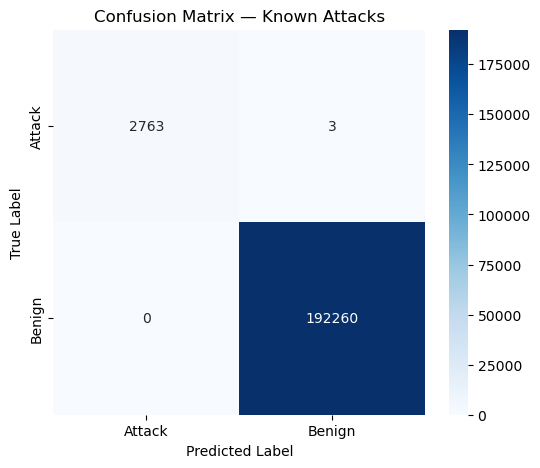

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Known attack confusion matrix
cm_known = confusion_matrix(y_known_test, y_known_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_known,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix — Known Attacks")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

#### Zero-day confusion matrix

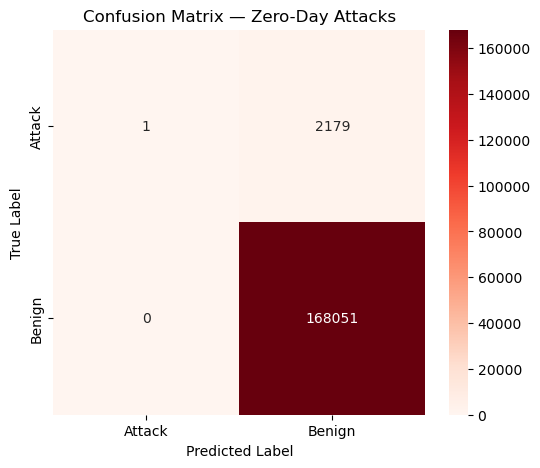

In [28]:
# Zero-day confusion matrix
cm_zero = confusion_matrix(y_zero_encoded, y_zero_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm_zero,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)

plt.title("Confusion Matrix — Zero-Day Attacks")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix for zero-day attacks shows that only 1 out of 2180 attack samples was correctly detected, while 2179 were misclassified as benign traffic. This demonstrates the inability of the supervised Random Forest model to generalize to unseen attack types. The model maintains a very low false positive rate, correctly classifying all benign samples. These results highlight the limitations of traditional supervised learning methods in zero-day attack detection.

#### Feature Importance


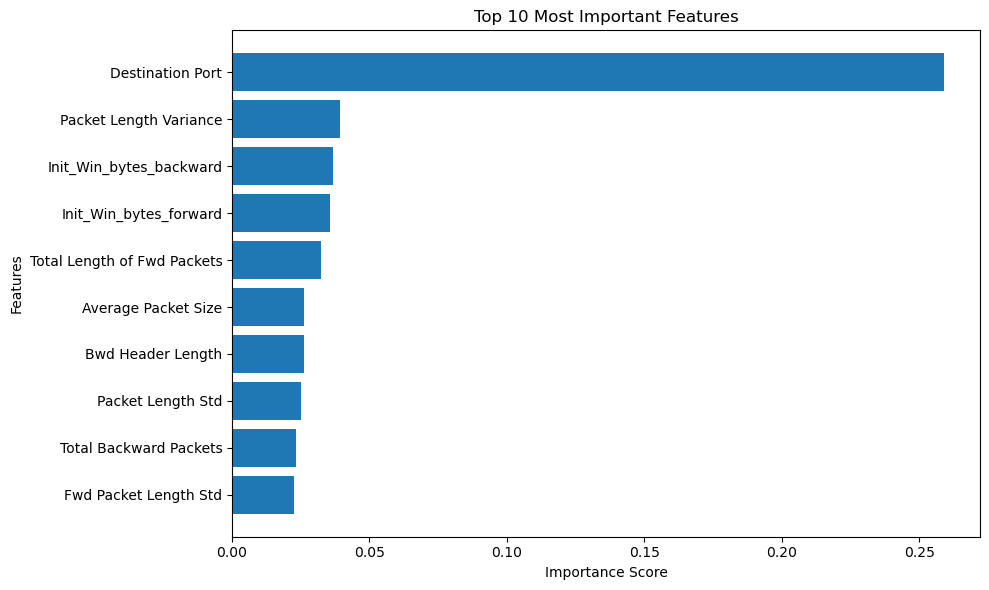

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# Sort features
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Plot top 10 features
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance_df['Feature'][:10][::-1],
    feature_importance_df['Importance'][:10][::-1]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

#### ROC curve

##### How does the model separates Attack vs Benign

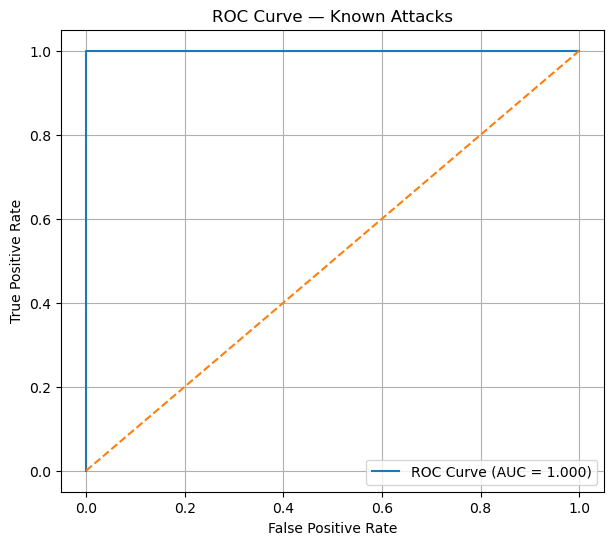

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get prediction probabilities
y_known_proba = rf_model.predict_proba(X_known_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_known_test, y_known_proba)

roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], linestyle='--')  # Random classifier line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Known Attacks")

plt.legend()
plt.grid()

plt.show()

### Precision–Recall Curve

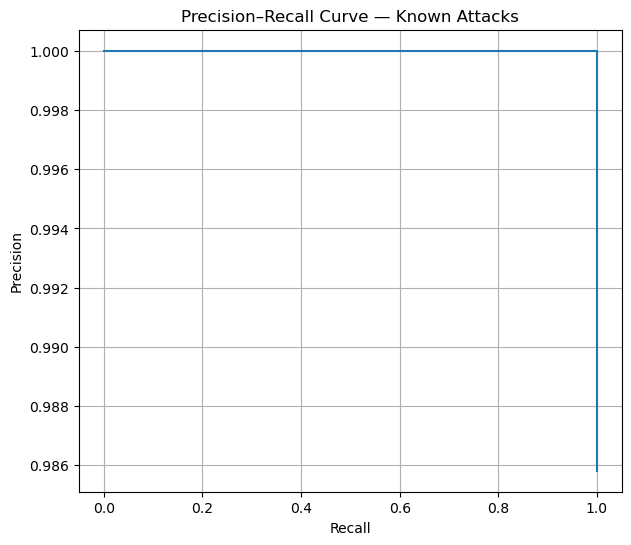

In [31]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall
precision, recall, thresholds = precision_recall_curve(
    y_known_test,
    y_known_proba
)

# Plot Precision-Recall curve
plt.figure(figsize=(7,6))

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title("Precision–Recall Curve — Known Attacks")

plt.grid()

plt.show()

## Unsupervised learning

### Training unsupervised model using only benign traffic

In [32]:
# Keep only benign samples for training
X_train_benign = X_train[y_train == "Benign"]

print("Benign training samples:", X_train_benign.shape)

from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_unsup = StandardScaler()

X_train_benign_scaled = scaler_unsup.fit_transform(X_train_benign)

# Scale zero-day data — keep feature names
X_zero_unsup_scaled = scaler_unsup.transform(
    pd.DataFrame(X_zero, columns=X_train.columns)
)

# Known dataset scaling — keep feature names
X_known_unsup_scaled = scaler_unsup.transform(
    pd.DataFrame(X_known_test, columns=X_train.columns)
)

print("Unsupervised scaling complete")

Benign training samples: (961294, 78)
Unsupervised scaling complete


### Isolation Forest and anomaly detection

#### Testing multiple contamination values

In [33]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report


contamination_values = [0.05, 0.1, 0.2, 0.3, 0.35, 0.4]

for contamination in contamination_values:

    iso_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        max_samples="auto",
        max_features=0.8,
        n_jobs=-1
    )

    # Train on benign traffic
    iso_model.fit(X_train_benign_scaled)

    # ==========================
    # Zero-day predictions
    # ==========================

    y_zero_pred = iso_model.predict(X_zero_unsup_scaled)

    y_zero_pred = np.where(
        y_zero_pred == -1,
        "Attack",
        "Benign"
    )

    print(f"\n=== Contamination: {contamination} ===")

    print("\nZero-Day Results:")

    print(
        classification_report(
            y_zero,
            y_zero_pred,
            zero_division=0
        )
    )

    # ==========================
    # Known attack predictions
    # ==========================

    # Decode known labels
    y_known_test_labels = label_encoder.inverse_transform(
        y_known_test
    )

    y_known_pred = iso_model.predict(
        X_known_unsup_scaled
    )

    y_known_pred = np.where(
        y_known_pred == -1,
        "Attack",
        "Benign"
    )

    print("\nKnown Attack Results:")

    print(
        classification_report(
            y_known_test_labels,
            y_known_pred,
            zero_division=0
        )
    )


=== Contamination: 0.05 ===

Zero-Day Results:
              precision    recall  f1-score   support

      Attack       0.01      0.04      0.02      2180
      Benign       0.99      0.95      0.97    168051

    accuracy                           0.94    170231
   macro avg       0.50      0.49      0.49    170231
weighted avg       0.97      0.94      0.96    170231


Known Attack Results:
              precision    recall  f1-score   support

      Attack       0.00      0.00      0.00      2766
      Benign       0.99      1.00      0.99    192260

    accuracy                           0.99    195026
   macro avg       0.49      0.50      0.50    195026
weighted avg       0.97      0.99      0.98    195026


=== Contamination: 0.1 ===

Zero-Day Results:
              precision    recall  f1-score   support

      Attack       0.01      0.04      0.01      2180
      Benign       0.99      0.90      0.94    168051

    accuracy                           0.89    170231
   macro a

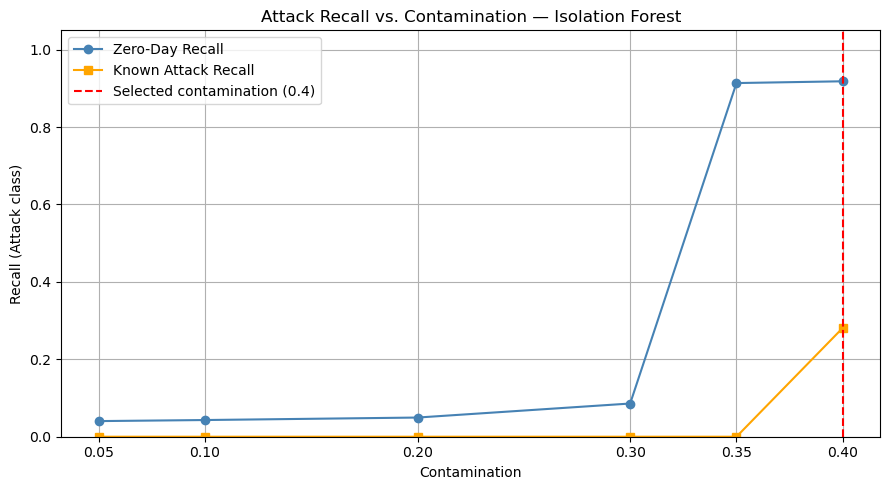

In [34]:
import matplotlib.pyplot as plt

recall_zero_day = []
recall_known = []

for contamination in contamination_values:

    iso_tmp = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42,
        max_samples="auto",
        max_features=0.8,
        n_jobs=-1
    )

    iso_tmp.fit(X_train_benign_scaled)

    # Zero-day recall
    y_zero_tmp = iso_tmp.predict(X_zero_unsup_scaled)
    y_zero_tmp = np.where(y_zero_tmp == -1, "Attack", "Benign")
    report_zero = classification_report(y_zero, y_zero_tmp, output_dict=True, zero_division=0)
    recall_zero_day.append(report_zero["Attack"]["recall"])

    # Known recall
    y_known_tmp = iso_tmp.predict(X_known_unsup_scaled)
    y_known_tmp = np.where(y_known_tmp == -1, "Attack", "Benign")
    y_known_test_labels = label_encoder.inverse_transform(y_known_test)
    report_known = classification_report(y_known_test_labels, y_known_tmp, output_dict=True, zero_division=0)
    recall_known.append(report_known["Attack"]["recall"])

# Plot
plt.figure(figsize=(9, 5))
plt.plot(contamination_values, recall_zero_day, marker='o', label='Zero-Day Recall', color='steelblue')
plt.plot(contamination_values, recall_known, marker='s', label='Known Attack Recall', color='orange')
plt.axvline(x=0.4, color='red', linestyle='--', label='Selected contamination (0.4)')
plt.title("Attack Recall vs. Contamination — Isolation Forest")
plt.xlabel("Contamination")
plt.ylabel("Recall (Attack class)")
plt.xticks(contamination_values)
plt.ylim(0, 1.05)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Final Isolation Forest Model (contamination = 0.4)

## Selection of Final Contamination Value

Multiple contamination values were tested (0.05, 0.1, 0.2, 0.3, 0.35, 0.4) to evaluate the performance of the Isolation Forest model on both known and zero-day attacks.

As the contamination value increased, the recall for attack detection improved, particularly for zero-day attacks. However, higher contamination values also introduced more false positives, meaning that more benign traffic was incorrectly classified as malicious.

Among the tested values, contamination = 0.4 provided the best balance between detecting zero-day attacks and maintaining acceptable detection performance on known attacks. This value achieved the highest recall for zero-day detection while still maintaining reasonable classification behavior on known traffic.

Therefore, contamination = 0.4 was selected as the final parameter for the Isolation Forest model.

In [35]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report

# ==========================
# Final contamination value
# ==========================

final_contamination = 0.4

iso_final = IsolationForest(
    n_estimators=200,
    contamination=final_contamination,
    random_state=42,
    max_samples="auto",
    max_features=0.8,
    n_jobs=-1
)

# Train model
iso_final.fit(X_train_benign_scaled)

# ==========================
# Zero-Day Predictions
# ==========================

y_zero_pred_final = iso_final.predict(
    X_zero_unsup_scaled
)

y_zero_pred_final = np.where(
    y_zero_pred_final == -1,
    "Attack",
    "Benign"
)

print("Final Zero-Day Results:")

zero_report = classification_report(
    y_zero,
    y_zero_pred_final,
    output_dict=True,
    zero_division=0
)

print(
    classification_report(
        y_zero,
        y_zero_pred_final,
        zero_division=0
    )
)

# ==========================
# Known Predictions
# ==========================

# Decode labels
y_known_test_labels = label_encoder.inverse_transform(
    y_known_test
)

y_known_pred_final = iso_final.predict(
    X_known_unsup_scaled
)

y_known_pred_final = np.where(
    y_known_pred_final == -1,
    "Attack",
    "Benign"
)

print("Final Known Results:")

known_report = classification_report(
    y_known_test_labels,
    y_known_pred_final,
    output_dict=True,
    zero_division=0
)

print(
    classification_report(
        y_known_test_labels,
        y_known_pred_final,
        zero_division=0
    )
)

# ==========================
# Store final metrics
# ==========================

ISO_zero_recall = zero_report["Attack"]["recall"]
ISO_zero_precision = zero_report["Attack"]["precision"]

ISO_known_recall = known_report["Attack"]["recall"]
ISO_known_precision = known_report["Attack"]["precision"]

print("\nStored Isolation Forest Metrics:")
print("ISO_zero_recall:", ISO_zero_recall)
print("ISO_zero_precision:", ISO_zero_precision)
print("ISO_known_recall:", ISO_known_recall)
print("ISO_known_precision:", ISO_known_precision)

Final Zero-Day Results:
              precision    recall  f1-score   support

      Attack       0.03      0.92      0.06      2180
      Benign       1.00      0.64      0.78    168051

    accuracy                           0.64    170231
   macro avg       0.52      0.78      0.42    170231
weighted avg       0.99      0.64      0.77    170231

Final Known Results:
              precision    recall  f1-score   support

      Attack       0.06      0.28      0.10      2766
      Benign       0.99      0.94      0.96    192260

    accuracy                           0.93    195026
   macro avg       0.53      0.61      0.53    195026
weighted avg       0.98      0.93      0.95    195026


Stored Isolation Forest Metrics:
ISO_zero_recall: 0.918348623853211
ISO_zero_precision: 0.032154960569216684
ISO_known_recall: 0.2812725958062184
ISO_known_precision: 0.06250502129027075


### Detecting anomalies in zero-day dataset

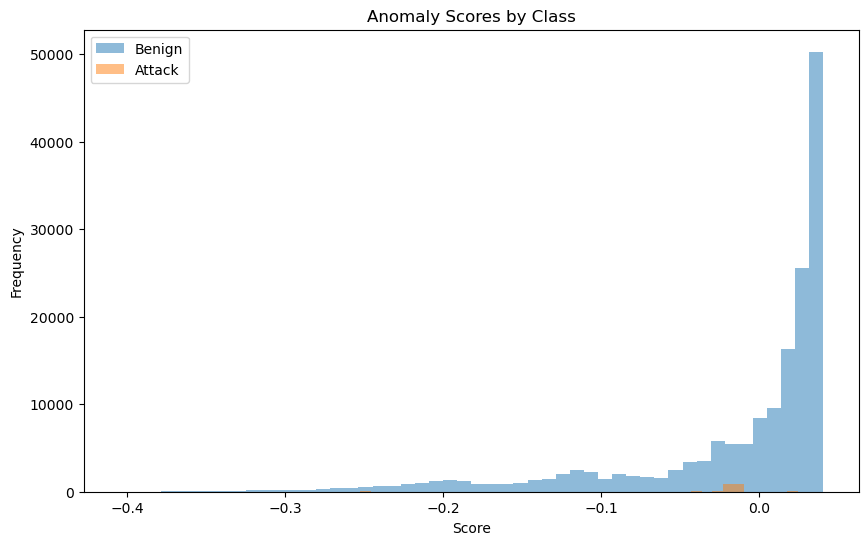

In [36]:
import matplotlib.pyplot as plt

scores = iso_final.decision_function(
    X_zero_unsup_scaled
)

plt.figure(figsize=(10,6))

plt.hist(
    scores[y_zero == "Benign"],
    bins=50,
    alpha=0.5,
    label="Benign"
)

plt.hist(
    scores[y_zero == "Attack"],
    bins=50,
    alpha=0.5,
    label="Attack"
)

plt.title("Anomaly Scores by Class")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### Confusion Matrix

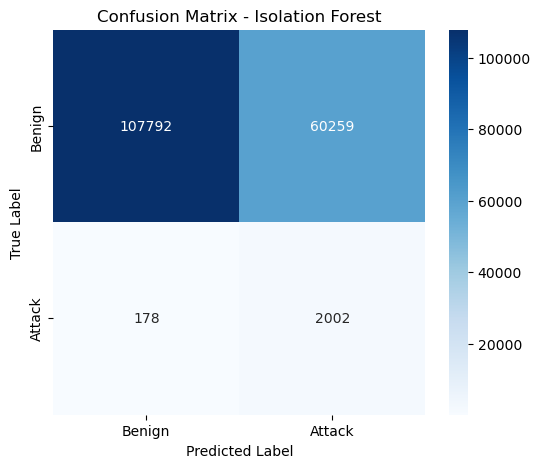

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(
    y_zero,
    y_zero_pred_final,
    labels=["Benign", "Attack"]
)

# Plot confusion matrix
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Attack"],
    yticklabels=["Benign", "Attack"]
)

plt.title("Confusion Matrix - Isolation Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

ROC-AUC score

In [38]:
from sklearn.metrics import roc_auc_score

scores = iso_final.decision_function(
    X_zero_unsup_scaled
)

auc = roc_auc_score(
    y_zero_encoded,
    -scores
)

print("ROC-AUC Score:", auc)

ROC-AUC Score: 0.30384204440122176


### ROC Curve Plot

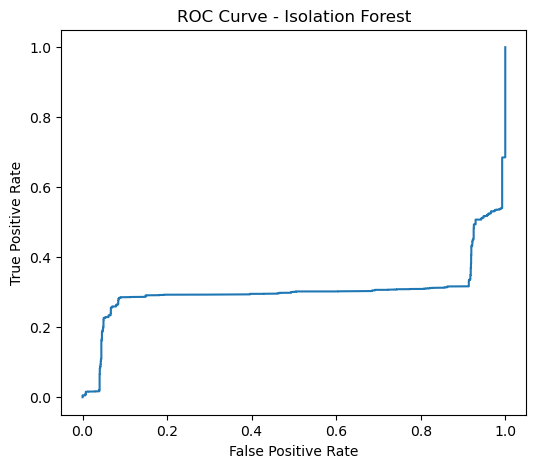

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_zero_encoded,
    -scores
)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr)

plt.title("ROC Curve - Isolation Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.show()

### Tableau comparatif Random Forest vs Isolation Forest

In [40]:
import pandas as pd

comparison_table = pd.DataFrame({

    "Model": [
        "Random Forest (supervised)",
        "Random Forest (supervised)",
        "Isolation Forest (unsupervised)",
        "Isolation Forest (unsupervised)"
    ],

    "Dataset": [
        "Known",
        "Zero-Day",
        "Known",
        "Zero-Day"
    ],

    "Recall_Attack": [
        RF_known_recall,
        RF_zero_recall,
        ISO_known_recall,
        ISO_zero_recall
    ],

    "Precision_Attack": [
        RF_known_precision,
        RF_zero_precision,
        ISO_known_precision,
        ISO_zero_precision
    ]

})

comparison_table

,Model,Dataset,Recall_Attack,Precision_Attack
0,Random Forest (supervised),Known,0.998915,1.000000
1,Random Forest (supervised),Zero-Day,0.000459,1.000000
2,Isolation Forest (unsupervised),Known,0.281273,0.062505
3,Isolation Forest (unsupervised),Zero-Day,0.918349,0.032155


The comparative results highlight clear differences between supervised and unsupervised detection approaches.

The Random Forest model achieved near-perfect recall and precision on known attacks, demonstrating its strong ability to recognize previously learned attack patterns. However, its performance on zero-day attacks was extremely poor, with almost no attack samples detected. This confirms that supervised models struggle to generalize to unseen threats that were not present in the training dataset.

In contrast, the Isolation Forest model showed strong detection capability for zero-day attacks, achieving a high recall of approximately 0.92. This demonstrates the effectiveness of anomaly detection techniques in identifying previously unseen malicious behavior. However, the precision values remained low, indicating that many benign samples were incorrectly classified as attacks. This highlights the common trade-off between detection sensitivity and false positive rate in anomaly-based systems.

Overall, the results confirm that supervised models are highly effective for detecting known threats, while unsupervised models provide better detection of unknown attacks. A hybrid detection strategy combining both methods would likely offer improved performance and greater reliability in real-world cybersecurity systems.

# Conclusion

This project evaluated the performance of supervised and unsupervised machine learning models for detecting known and zero-day cyber attacks using the CICIDS2017 dataset.

The supervised Random Forest model achieved excellent performance when detecting known attacks. The model produced near-perfect classification results on known test data, demonstrating its ability to learn patterns from labeled attack traffic. However, when evaluated on zero-day attacks from the Thursday dataset, the model failed to generalize to previously unseen attack types. Almost all zero-day attack samples were misclassified as benign traffic, highlighting a major limitation of supervised learning methods when encountering novel threats.

In contrast, the unsupervised Isolation Forest model demonstrated strong anomaly detection capabilities when trained using only benign traffic. By tuning the contamination parameter, the model was able to detect a large proportion of zero-day attacks, achieving high recall values. However, this improved detection performance came at the cost of a large number of false positives, as many benign traffic samples were incorrectly classified as anomalies. This behavior reflects a common challenge in anomaly-based intrusion detection systems, where increasing detection sensitivity often leads to higher false alarm rates.

Another important observation is the sensitivity of the Isolation Forest model to the contamination parameter. The performance of the unsupervised model varied significantly depending on the selected contamination value, which directly controls the proportion of expected anomalies. In this project, the parameter was tuned experimentally using labeled data, allowing the selection of a value that maximized detection performance.

However, in real-world deployment scenarios, the true proportion of anomalous traffic is typically unknown and constantly changing. As a result, selecting an optimal contamination value becomes much more difficult, and the actual performance of the Isolation Forest model would likely be lower than what was observed in this controlled experimental setting. This sensitivity reinforces the practical trade-offs between supervised and unsupervised approaches, particularly in operational cybersecurity environments where parameter estimation is uncertain.

The comparison between supervised and unsupervised models clearly illustrates the trade-offs between both approaches. Supervised models provide highly accurate detection of known attacks but struggle to detect previously unseen threats. Unsupervised models, on the other hand, are capable of identifying unknown attack patterns but tend to generate higher false positive rates.

Overall, the results demonstrate that neither approach alone is sufficient for reliable intrusion detection. A hybrid detection strategy combining supervised classification for known threats and unsupervised anomaly detection for zero-day attacks would likely provide more robust and reliable intrusion detection in real-world cybersecurity environments, leveraging the complementary strengths of both paradigms while mitigating their individual limitations.